# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Sinara Meyda Setio Putri
- **Email:** cdcc180d6x1032@student.devacademy.id
- **ID Dicoding:** CDCC180D6X1032

Latar Belakang

Proyek ini bertujuan untuk menganalisis E-Commerce Public Dataset guna memahami perkembangan performa penjualan, kategori produk yang paling berkontribusi terhadap revenue, serta karakteristik pelanggan berdasarkan analisis RFM. Hasil analisis ini diharapkan dapat memberikan insight yang berguna dalam mendukung pengambilan keputusan bisnis.

## Menentukan Pertanyaan Bisnis

- Bagaimana perkembangan jumlah pesanan dan total revenue setiap bulan selama periode September 2016 hingga Agustus 2018, serta pada bulan apa terjadi perubahan yang paling signifikan?
- Kategori produk apa saja yang memberikan kontribusi revenue terbesar selama periode tersebut, dan kategori mana yang memiliki potensi untuk terus dikembangkan?
- Bagaimana pola perilaku pelanggan berdasarkan analisis Recency, Frequency, dan Monetary (RFM), serta pelanggan seperti apa yang sebaiknya menjadi fokus dalam upaya meningkatkan retensi?

## Import Semua Packages/Library yang Digunakan

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Data Wrangling

In [137]:
from pathlib import Path

BASE_DIR = Path('/content/')

### Gathering Data

In [138]:
customers_df = pd.read_csv(BASE_DIR / "customers_dataset.csv")
orders_df = pd.read_csv(BASE_DIR / "orders_dataset.csv")
order_items_df = pd.read_csv(BASE_DIR / "order_items_dataset.csv")
order_payments_df = pd.read_csv(BASE_DIR / "order_payments_dataset.csv")
products_df = pd.read_csv(BASE_DIR / "products_dataset.csv")
category_df = pd.read_csv(BASE_DIR / "product_category_name_translation.csv")

**Insight:**

- Dataset E-Commerce Public terdiri dari beberapa tabel yang saling terhubung melalui kolom kunci seperti 'order_id', 'product_id', dan 'customer_id', sehingga membentuk struktur data relasional.
- Tabel 'orders_dataset' berperan sebagai pusat data transaksi yang menyimpan informasi utama seperti waktu pemesanan dan status order.
- Tabel 'order_items_dataset' memberikan detail produk dalam setiap pesanan, termasuk harga dan jumlah item, sehingga dapat digunakan untuk analisis revenue.
- Tabel 'order_payments_dataset' menyimpan informasi terkait metode dan nilai pembayaran yang memungkinkan analisis lebih lanjut terkait kontribusi pembayaran terhadap transaksi.
- Tabel 'products_dataset' berisi informasi penduduk, termasuk kategori yang kemudian diterjemahkan ke dalam bahasa inggris menggunakan 'product_category_name_translation' agar lebih mudah untuk dianalisis.
- Tabel 'customers_dataset' menyediakan informasi pelanggan yang memungkinkan analisis perilaku pelanggan seperti frekuensi pembelian dan segmentasi.
- Dengan menggabungkan seluruh tabel tersebut dataset ini akan menganalisis lebih mendalam seperti tren penjualan, kontribusi kategori produk terhadap revenue, serta analisis perilaku pelanggan menggunakan pendekatan RFM.
- Struktur dataset ini mempresentasikan sistem transaksi E-Commerce yang nyata sehingga hasil analisis dapat digunakan untuk memahami kondisi bisnis secara lebih realistis.


### Assessing Data

In [139]:
orders_df.info()
orders_df.isnull().sum()
products_df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


**Insight:**

- Dataset 'orders_df' terdiri dari 99.441 entri dengan 8 kolom yang menunjukkan bahwa data transaksi memiliki jumlah observasi yang cukup besar untuk dianalisis.
- Beberapa kolom pada 'orders_df' masih memiliki missing value terutama pada kolom terkait proses oengiriman seperti 'order_approved_at', 'order_delivered_carrier_date' dan 'order_delivered_customer_date'. Hal ini kemungkinan disebabkan oleh adanya pesanan yang belum selesai atau dibatalkan.
- Seluruh kolom pada 'orders_df' masih bertipe data 'object', termasuk kolom tanggal, sehingga perlu dilakukan konversi ke tipe  'datetime' agar dapat digunakan untuk analisis berbasis waktu.
- Pada dataset 'products_df', terdapat missing value yang cukup signifikan pada kolom 'product_category_name', 'product_name_length','product_description_length', dan 'product_photos_qty' dimana masing-masing sebanyak 610 data. Hal ini dapat mempengaruhi analisis kategori produk jika tidak dibenahi.
- Beberapa kolom terkait dimensi produk seperti 'product_weight_g', 'product_length_cm', 'product_height_cm', dan 'product_width_cm' memiliki missing value dengan jumlah kecil, sehingga dapat dibenahi tanpa terlalu mempengaruhi keseluruhan analisis.
- Secara keseluruhan, dataset memerlukan proses cleaning terutama pada penanganan missing value dan konversi tipe data sebelum digunakan dalam tahap analisis lebih lanjut.
- Tahap Assessing ini penting untuk memastikan kualitas data sebelum dilakukan analisis lebih lanjut agar hasil yang diperoleh lebih akurat dan dapat dipercaya.

### Cleaning Data

In [140]:
datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date"
]

for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")

products_df = products_df.merge(
    category_df,
    on="product_category_name",
    how="left"
)

products_df["product_category_name_english"] = products_df["product_category_name_english"].fillna("unknown")

**Insight:**
- Kolom-kolom yang berkaitan dengan waktu seperti 'order_purchase_timestamp', 'order_approved_at', dan 'order_delivered_customer_date' telah dikonversi ke tipe data 'datetime' agar dapat digunakan dalam analisis berbasis waktu, seperti tren bulanan dan perhitungan recency.
- Proses ini penting karena sebelumnya seluruh kolom bertipe 'object' yang tidak optimal untuk analisis waktu dan dapat menyebabkan kesalahan dalam perhitungan.
- Missing value pada kolom 'product_category_name' di dataset 'products_df' telah diisi dengan nilai "unknown" untuk mencegah kehilangan data saat proses agregasi dan visualisasi.
- Dataset 'products_df' kemudian digabungkan dengan 'product_category_name_translation' untuk mendapatkan nama kategori dalam bahasa inggris, sehiingga hasil analisis lebih mudah dipahami.
- Missing value pada kolom 'product_category_name_english' juga ditangani dengan mengisi nilai "unknown" untuk memastikan tidak ada data kategori yang hilang setelah proses merge.
- Secara keseluruhan proses Cleaning ini bertujuan untuk meningkatkan kualitas data sehingga analisis yang dilakukan menjadi lebih akurat, konsisten, dan dapat diandalkan.
- Tahap Cleaning Data ini menjadi fondasi penting sebelum melakukan analisis lebih lanjut, karena kualitas data yang baik akan menghasilkan insight yang lebih valid.

## Exploratory Data Analysis (EDA)

### Explore ...

In [141]:
all_df = orders_df.merge(order_items_df, on="order_id", how="inner")
all_df = all_df.merge(products_df, on="product_id", how="left")
all_df = all_df.merge(customers_df, on="customer_id", how="left")
all_df = all_df.merge(order_payments_df, on="order_id", how="left")

all_df["order_month"] = all_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

### Pertanyaan 1 : Bagaimana perkembangan jumlah pesanan dan total revenue setiap bulan selama periode September 2016 hingga Agustus 2018, serta pada bulan apa terjadi perubahan yang paling signifikan?

In [142]:
monthly_orders = all_df.groupby("order_month")["order_id"].nunique().reset_index()
monthly_revenue = all_df.groupby("order_month")["price"].sum().reset_index()

### Pertanyaan 2 : Kategori produk apa saja yang memberikan kontribusi revenue terbesar selama periode tersebut, dan kategori mana yang memiliki potensi untuk terus dikembangkan?

In [143]:
category_revenue = (
    all_df.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

### Pertanyaan 3 : Bagaimana pola perilaku pelanggan berdasarkan analisis Recency, Frequency, dan Monetary (RFM), serta pelanggan seperti apa yang sebaiknya menjadi fokus dalam upaya meningkatkan retensi?

In [144]:
rfm_df = all_df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "price": "sum"
}).reset_index()

rfm_df.columns = ["customer_id", "last_order", "frequency", "monetary"]

recent_date = all_df["order_purchase_timestamp"].max()
rfm_df["recency"] = (recent_date - rfm_df["last_order"]).dt.days

**Insight:**
- Proses penggabungan beberapa tabel (`orders_df', 'order_items_df', 'products_df', 'customers_df', dan 'oreder_payments_df') menghasilkan satu dataset ('all_df') yang mencakup informasi transaksi, produk, pelanggan, dan pembayaran. Hal ini memungkinkan analisis dilakukan secara lebih komprehensif.  
- Penambahan kolom 'order_month' dari 'order_purchase_timestamp' memudahkan analisis berbasis waktu, khususnya untuk melihat tren jumlah pesanan dan revenue per bulan.
- Hasil agregasi menunjukkan bahwa jumlah pesanan dihitung berdasarkan 'order_id' unik, sedangkan revenue dihitung dari total 'price' yang merupakan pendekatan yang tepat untuk menggambarkan peforma transaksi.
- Analisis berdasarkan kategori produk menunjukkan bahwa kontribusi revenue tidak merata, di mana beberapa kategori produk memiliki peran yang jauh lebih besar dibandingkan kategori lainnya.
- Pembentukan dataset RFM ('recency', 'frequency', 'monetary') memungkinkan analisis perilaku pelanggan dengan 'recency' menunjukkan seberapa baru pelanggan melakukan transaksi, 'frequency' menunjukkan seberapa sering pelanggan melakukan pembelian, dan 'monetary' menunjukkan total nilai transaksi pelanggan.
- Dengan adanya RFM, dataset tidak hanya dapat digunakan untuk analisis deskriptif, tetapi juga untuk memahami segmentasi pelanggan dan potensi strategi bisnis yang lebih lanjut.
- Tahap EDA ini menjadi dasar untuk menjawab pertanyaan bisnis yang telah ditentukan, sekaligus memastikan bahwa data yang digunakan sudah siap untuk divisualisasikan dan dianalisis lebih lanjut.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perkembangan jumlah pesanan dan total revenue setiap bulan selama periode September 2016 hingga Agustus 2018, serta pada bulan apa terjadi perubahan yang paling signifikan?

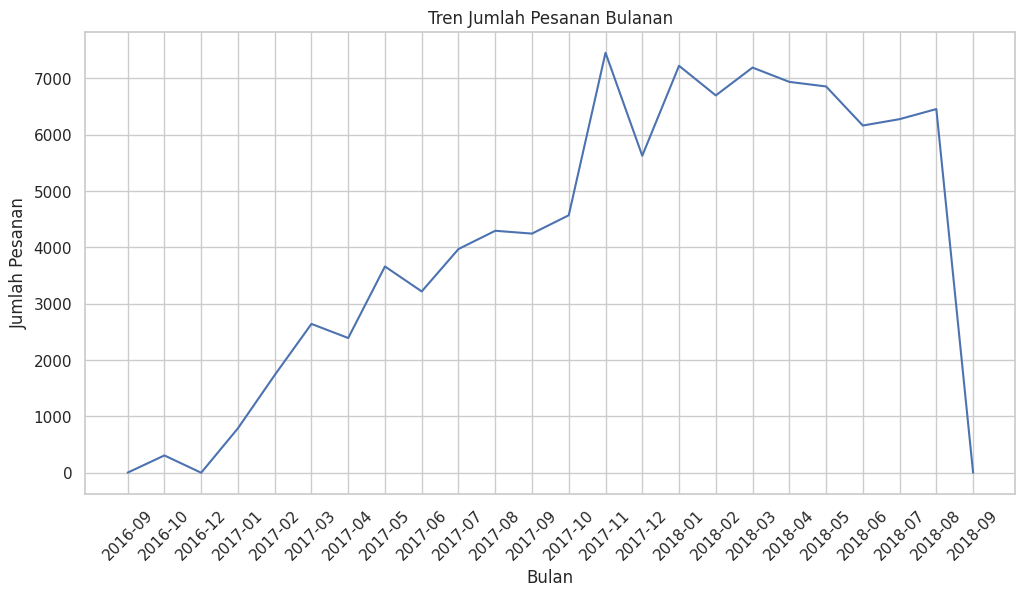

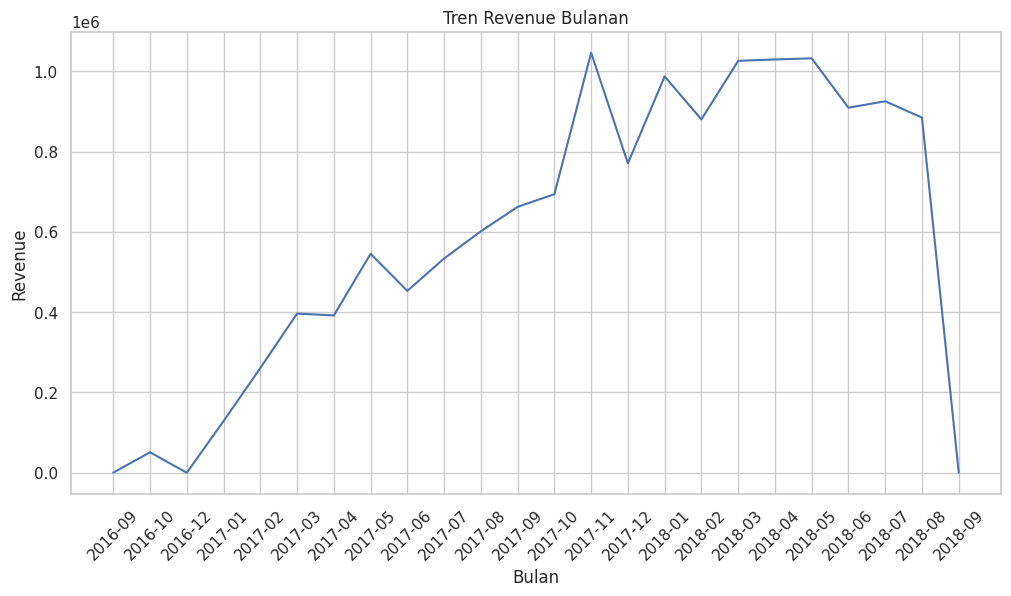

In [145]:
sns.lineplot(data=monthly_orders, x="order_month", y="order_id")
plt.xticks(rotation=45)
plt.title("Tren Jumlah Pesanan Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Pesanan")
plt.show()

sns.lineplot(data=monthly_revenue, x="order_month", y="price")
plt.xticks(rotation=45)
plt.title("Tren Revenue Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Revenue")
plt.show()

### Pertanyaan 2: Kategori produk apa saja yang memberikan kontribusi revenue terbesar selama periode tersebut, dan kategori mana yang memiliki potensi untuk terus dikembangkan?

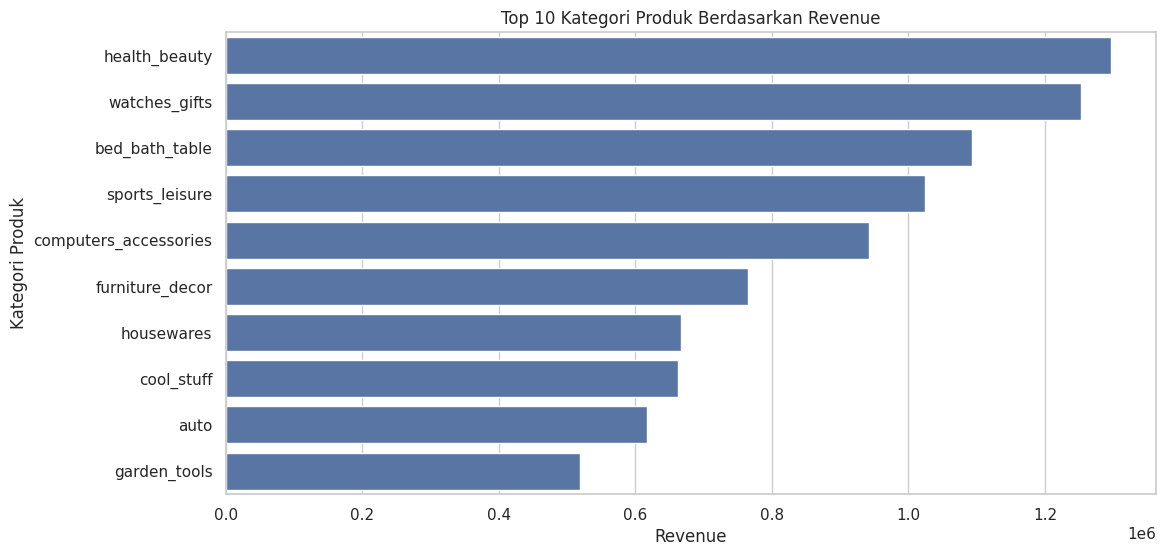

In [146]:
top_category = category_revenue.head(10)

sns.barplot(data=top_category, x="price", y="product_category_name_english")
plt.title("Top 10 Kategori Produk Berdasarkan Revenue")
plt.xlabel("Revenue")
plt.ylabel("Kategori Produk")
plt.show()

### Pertanyaan 3: Bagaimana pola perilaku pelanggan berdasarkan analisis Recency, Frequency, dan Monetary (RFM), serta pelanggan seperti apa yang sebaiknya menjadi fokus dalam upaya meningkatkan retensi?

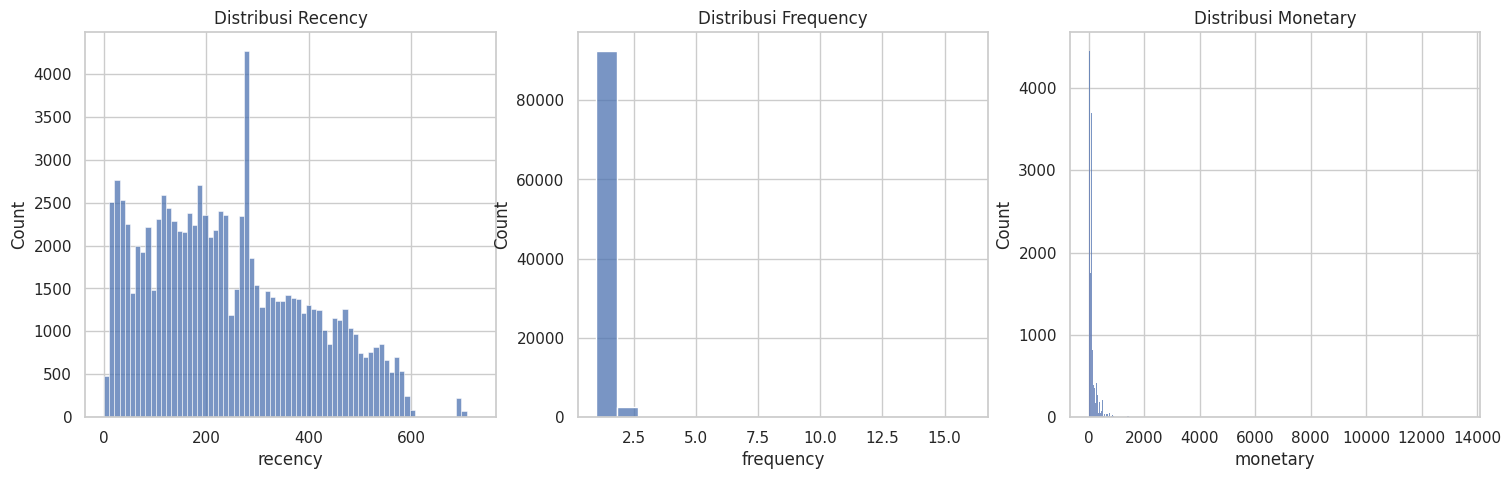

In [147]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_df["recency"], ax=ax[0])
ax[0].set_title("Distribusi Recency")

sns.histplot(rfm_df["frequency"], ax=ax[1])
ax[1].set_title("Distribusi Frequency")

sns.histplot(rfm_df["monetary"], ax=ax[2])
ax[2].set_title("Distribusi Monetary")

plt.show()

**Insight:**

Pertanyaan 1 :
- Tren pesanan dan revenue mengalami pola yang cenderung meningkat dari tahun 2016 hingga mencapai puncaknya di sekitar akhir tahun 2017 hingga awal tahun 2018. Hal ini mengindikasikan adanya pertumbuhan aktivitas transaksi dalam periode tersebut.
- Setelah mencapai puncak, terlihat adanya fluktuasi pada jumlah pesanan dan revenue yang menunjukkan bahwa bisnis tidak stabil pada setiap bulan. Fluktuasi ini kemungkinan dipengaruhi oleh faktor musiman, promosi, atau perubahan perilaku pelanggan.
- Pola tren antara jumlah pesanan dan revenue terlihat sejalan, di mana peningkatan jumlah pesanan diikuti dengan peningkatan revenue. Hal ini menunjukkan bahwa volume transaksi memiliki kontribusi langsung terhadap total pendapatan.
- Terdapat penurunan yang sangat drastis hingga mendekati nol pada bulan terakhir. Penurunan ini tidak mencerminkan kondisi bisnis yang sebenarnya, melainkan kemungkinan disebabkan oleh data yang velum lengkap pada periode tersebut.
- Secara keseluruhan tren menunjukkan bahwsa bisnis mengalami pertiumbuhan hingga periode tertentu, namun tetap menghadapi fluktuasi yang perlu dianalisis lebih lanjut untuk memahami faktor penyebabnya.

Pertanyaan 2:
- Kategori produk 'health_beauty' merupakan kontributor revenue terbesar dibandingkan kategori lainnya, kemudian 'watches_gifts' dan 'bed_bath_table'. Hal ini menunjukkan bahwa produk-produk dalam kategori tersebut memiliki permintaan yang tinggi di platform e-commerce ini.
- Kategori seperti 'sports_leisure' dan 'computers_accessories' juga memberikan kontribusi yang signifikan terhadap revenue, meskipun berada di bawah tiga kategori utama. Ini mengindikasi bahwa produk terkait gaya hidup dan teknologi juga memiliki pasar yang cukup kuat.
- Perbedaan kontribusi revenue antar kategori terlihat cukup signifikan yang menunjukkan bahwa distribusi penjualan tidak merata. Beberapa kategori mendominasi, sementara kategori lainnya memberikan kontribusi yang lebih kecil.
- Dominasi kategori tertentu dapat disebabkan oleh beberapa faktor seperti tingkat kebutuhan pelanggan, harga produk yang relatif lebih tinggi, atau frekuensi pembelian yang lebih sering.
- Informasi ini dapat dimanfaatkan oleh bisnis untuk memnentukan strategi seperti, memprioritaskan stok pada kategori dengan performa tinggi, meningkatkan promosi pada kategori unggulan, serta mengevaluasi kategori dengan performa rendah untuk pengembangan lebih lanjut.

Pertanyaan 3:
- Distribusi 'recency' menunjukkan bahwa sebagian besar pelanggan memiliki nilai recency yang cukup tinggi, yang berarti sudah cukup lama sejak mereka melakukan transaksi terakhir. Hal ini mengindikasikan bahwa banyak pelanggan yang tidak aktif atau belum melakukan pembelian kembali dalam waktu dekat.
- Distribusi 'frequency' dangat condong ke nilai rendah, di mana mayoritas pelanggan hanya melakukan sedikit transaksi umumnya 1-2 kali. Ini menunjukkan bahwa sebagian besar pelanggan merupakan pembeli yang sesekali, bukan pelanggan yang loyal.
- Distribusi 'monetary' menunjukkan pola yang tidak merata dengan sebagian besar pelanggan memiliki nilai pembelian yang relatif kecil, sementgara hanya sedikit pelanggan yang memiliki nilai transaksi tinggi. Hal ini mengindikasikan bahwa kontribusi revenue kemungkinan didominasi oleh sebagian kecil pelanggan.
- Ketiga distribusi ini menunjukkan bahwa basis pelanggan cenderung didominasi oleh pelanggan dengan aktivitas rendah, baik dari sisi frekuensi maupun nilai transaksi.
- Berdasarkan pola RFM ini terdapat peluang bagi bisnis untuk meningkatkan retensi pelanggan, misalnya dengan promosi, program, loyalitas, atau personalisasi penawarn untuk mendorong pelanggan melakukan pembelian ulang.
- Selain itu pelanggan dengan nilai monetary tinggi dapat diidentifikasi sebagai pelanggan bernilai tinggi yang perlu dipertahankan melalui strategi khusus.

## Analisis Lanjutan (Opsional)

In [148]:
rfm_df.describe()

,last_order,frequency,monetary,recency
count,95420,95420.000000,95420.000000,95420.000000
mean,2018-01-03 03:15:08.361150464,1.034018,148.912705,242.600377
min,2016-09-04 21:15:19,1.000000,0.850000,0.000000
25%,2017-09-15 21:20:53.750000128,1.000000,48.900000,118.000000
50%,2018-01-22 14:46:53.500000,1.000000,89.900000,223.000000
75%,2018-05-07 09:29:34.750000128,1.000000,159.900000,352.000000
max,2018-09-03 09:06:57,16.000000,13440.000000,728.000000
std,NaN,0.211234,248.583783,153.160320


## Conclusion

- ## Conclusion

Berdasarkan hasil analisis E-Commerce Public Dataset selama periode September 2016 hingga Agustus 2018, diperoleh beberapa kesimpulan sebagai berikut:
- Dari sisi perkembangan bisnis, jumlah pesanan dan total revenue menunjukkan tren yang cenderung meningkat hingga mencapai puncak pada akhir 2017 hingga awal 2018. Setelah itu, terlihat adanya fluktuasi pada beberapa bulan berikutnya yang menunjukkan bahwa performa penjualan tidak selalu stabil. Hal ini mengindikasikan bahwa meskipun bisnis sempat mengalami pertumbuhan yang signifikan, tetap terdapat dinamika perubahan permintaan dari waktu ke waktu.
- Dari sisi produk, kategori seperti *health_beauty*, *watches_gifts*, dan *bed_bath_table* merupakan kontributor utama terhadap total revenue. Hal ini menunjukkan bahwa kategori tersebut memiliki permintaan yang tinggi dan berperan penting dalam performa bisnis. Selain itu, distribusi revenue yang tidak merata mengindikasikan bahwa hanya beberapa kategori yang mendominasi penjualan dibandingkan kategori lainnya, sehingga kategori unggulan tersebut dapat menjadi fokus dalam strategi pengembangan bisnis.
- Dari sisi pelanggan, berdasarkan analisis RFM, sebagian besar pelanggan memiliki frekuensi transaksi yang rendah dan nilai pembelian yang relatif kecil, yang menunjukkan bahwa mayoritas pelanggan merupakan pembeli sesekali. Selain itu, banyak pelanggan memiliki nilai recency yang tinggi, yang mengindikasikan bahwa mereka sudah lama tidak melakukan transaksi. Namun, terdapat sebagian kecil pelanggan dengan nilai monetary tinggi yang memberikan kontribusi besar terhadap revenue, sehingga kelompok pelanggan ini perlu dipertahankan melalui strategi khusus seperti program loyalitas atau promosi yang lebih personal.

Secara keseluruhan, hasil analisis menunjukkan bahwa meskipun bisnis mengalami pertumbuhan pada periode tertentu, terdapat peluang besar untuk meningkatkan retensi pelanggan dan mengoptimalkan kategori produk unggulan guna meningkatkan performa bisnis secara berkelanjutan.

In [132]:
!pip install streamlit

In [149]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(
    page_title="Dashboard Analisis E-Commerce",
    layout="wide"
)

sns.set(style="whitegrid")

@st.cache_data
def load_data():
    zip_path = "E-commerce-public-dataset.zip"
    extract_path = "ecommerce_data"

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    base_path = os.path.join(extract_path, "E-Commerce Public Dataset")

    customers_df = pd.read_csv(os.path.join(base_path, "customers_dataset.csv"))
    orders_df = pd.read_csv(os.path.join(base_path, "orders_dataset.csv"))
    order_items_df = pd.read_csv(os.path.join(base_path, "order_items_dataset.csv"))
    order_payments_df = pd.read_csv(os.path.join(base_path, "order_payments_dataset.csv"))
    products_df = pd.read_csv(os.path.join(base_path, "products_dataset.csv"))
    category_df = pd.read_csv(os.path.join(base_path, "product_category_name_translation.csv"))

    datetime_cols = [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_customer_date"
    ]

    for col in datetime_cols:
        orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

    products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")

    products_df = products_df.merge(
        category_df,
        on="product_category_name",
        how="left"
    )

    products_df["product_category_name_english"] = products_df["product_category_name_english"].fillna("unknown")

    all_df = orders_df.merge(order_items_df, on="order_id", how="inner")
    all_df = all_df.merge(products_df, on="product_id", how="left")
    all_df = all_df.merge(customers_df, on="customer_id", how="left")
    all_df = all_df.merge(order_payments_df, on="order_id", how="left")

    all_df["order_month"] = all_df["order_purchase_timestamp"].dt.to_period("M").astype(str)
    all_df["order_date"] = all_df["order_purchase_timestamp"].dt.date

    return all_df


all_df = load_data()

st.title("📊 Dashboard Analisis E-Commerce")
st.caption("Periode Analisis: September 2016 - Agustus 2018")

st.sidebar.header("Filter Dashboard")

min_date = all_df["order_date"].min()
max_date = all_df["order_date"].max()

date_range = st.sidebar.date_input(
    "Pilih Rentang Tanggal",
    value=(min_date, max_date),
    min_value=min_date,
    max_value=max_date
)

if len(date_range) == 2:
    start_date, end_date = date_range
else:
    start_date, end_date = min_date, max_date

category_options = sorted(all_df["product_category_name_english"].dropna().unique())

selected_categories = st.sidebar.multiselect(
    "Pilih Kategori Produk",
    options=category_options,
    default=category_options[:10]
)

filtered_df = all_df[
    (all_df["order_date"] >= start_date) &
    (all_df["order_date"] <= end_date) &
    (all_df["product_category_name_english"].isin(selected_categories))
]

if filtered_df.empty:
    st.warning("Tidak ada data untuk filter yang dipilih.")
    st.stop()

st.subheader("Ringkasan Utama")

total_orders = filtered_df["order_id"].nunique()
total_revenue = filtered_df["price"].sum()
total_customers = filtered_df["customer_unique_id"].nunique()

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Total Orders", f"{total_orders:,}")

with col2:
    st.metric("Total Revenue", f"{total_revenue:,.2f}")

with col3:
    st.metric("Total Customers", f"{total_customers:,}")

monthly_orders = filtered_df.groupby("order_month")["order_id"].nunique().reset_index()
monthly_revenue = filtered_df.groupby("order_month")["price"].sum().reset_index()

st.subheader("Tren Jumlah Pesanan")

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=monthly_orders, x="order_month", y="order_id", marker="o", ax=ax)
plt.xticks(rotation=45)
st.pyplot(fig)

st.subheader("Tren Revenue")

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=monthly_revenue, x="order_month", y="price", marker="o", ax=ax)
plt.xticks(rotation=45)
st.pyplot(fig)

category_revenue = (
    filtered_df.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

st.subheader("Top 10 Kategori Produk Berdasarkan Revenue")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=category_revenue, x="price", y="product_category_name_english", ax=ax)
st.pyplot(fig)

rfm_df = filtered_df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "price": "sum"
}).reset_index()

rfm_df.columns = ["customer_id", "last_order", "frequency", "monetary"]

recent_date = filtered_df["order_purchase_timestamp"].max()
rfm_df["recency"] = (recent_date - rfm_df["last_order"]).dt.days

st.subheader("Distribusi RFM")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm_df["recency"], ax=ax[0])
ax[0].set_title("Recency")

sns.histplot(rfm_df["frequency"], ax=ax[1])
ax[1].set_title("Frequency")

sns.histplot(rfm_df["monetary"], ax=ax[2])
ax[2].set_title("Monetary")

st.pyplot(fig)

st.subheader("Insight Utama")

st.markdown("""
- Tren pesanan dan revenue menunjukkan peningkatan hingga akhir 2017 sebelum mengalami fluktuasi, yang mengindikasikan dinamika permintaan dari waktu ke waktu.

- Kategori produk seperti *health_beauty*, *watches_gifts*, dan *bed_bath_table* menjadi kontributor utama revenue dan dapat diprioritaskan dalam strategi bisnis.

- Sebagian besar pelanggan memiliki frekuensi pembelian rendah, yang menunjukkan dominasi pembeli sesekali.

- Sebagian kecil pelanggan dengan nilai transaksi tinggi memberikan kontribusi besar terhadap revenue, sehingga perlu difokuskan dalam strategi retensi.
""")

Overwriting dashboard.py


In [150]:
!ls

customers_dataset.csv	    product_category_name_translation.csv
dashboard.py		    products_dataset.csv
ecommerce_data		    README.md
order_items_dataset.csv     requirements.txt
order_payments_dataset.csv  sample_data
order_reviews_dataset.csv   sellers_dataset.csv
orders_dataset.csv


In [151]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [152]:
!streamlit run dashboard.py & lt --port 8051

your url is: https://yellow-adults-grin.loca.lt



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.228.5.144:8501

  Stopping...
^C


In [153]:
%%writefile requirements.txt
streamlit
pandas
numpy
matplotlib
seaborn

Overwriting requirements.txt


In [154]:
%%writefile README.md
Proyek Analisis Data E-Commerce

Deskripsi Proyek
Proyek ini bertujuan untuk menganalisis E-Commerce Public Dataset guna memahami tren pesanan, kategori produk dengan kontribusi revenue terbesar, serta karakteristik pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary).

Pertanyaan Bisnis
1. Bagaimana perkembangan jumlah pesanan dan total revenue setiap bulan selama periode September 2016 hingga Agustus 2018?
2. Kategori produk apa saja yang memberikan kontribusi revenue terbesar?
3. Bagaimana karakteristik pelanggan berdasarkan analisis RFM?

Struktur Folder
- `Proyek_Analisis_Data.ipynb`
- `dashboard.py`
- `requirements.txt`
- `README.md`
- `E-commerce-public-dataset.zip`

Setup Environment
Install dependensi dengan perintah berikut:

```bash
pip install -r requirements.txtProyek Analisis Data E-Commerce

Analisis data e-commerce untuk melihat tren pesanan, kategori produk, dan karakteristik pelanggan.

pip install -r requirements.txt
streamlit run dashboard.py

Overwriting README.md
